# Chapter 7 | Dimensionality Reduction

## Table of Contents
1. [Introduction](#1-introduction)
2. [Curse of Dimensionality](#2-curse-of-dimensionality)
3. [Main Approaches for Dimensionality Reduction](#3-main-approaches-for-dimensionality-reduction)
    - [Projection](#projection)
    - [Manifold Learning](#manifold-learning)
4. [Main Algorithms for Dimensionality Reduction](#4-main-algorithms-for-dimensionality-reduction)
    - [PCA](#pca)
    - [Random Projection](#random-projection)
    - [Locally Linear Embedding (LLE)](#locally-linear-embedding-lle)
    - [Others](#others)

## 1. Introduction
When dealing with huge amount of features (thousands or even millions of features) there can be various motivations for which to reduce dimensions:
- speed up training;
- fighting the **Curse of Dimensionality** (much harder to find a good solution);
- removing redundancy or noise;
- data visualization (reducing to 2 or 3 dimensions help us set things on a graph and communicate conclusions to people not familiar with data science).

Notice how reducing dimensionality can drop useful information, making the system performing slightly worse (which may be not desired); moreover, some models, such as **Neural Networks**, can handle high-dimensional data efficiently learning to reduce its dimensionality preserving the useful information for the task. This underlines how Dimensionality Reduction won't always be of help.

## 2. Curse of Dimensionality
For an human mind, is hard to visualize an high-dimensional space (even a 4D hypercube is incredibly hard to picture):

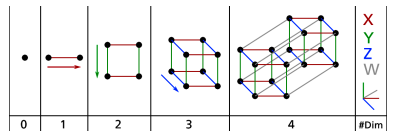

It turns out that things behave very differently in high-dimensional space: for example, picking a random point in a unit square ($1 \times 1$ square), it will have a 0.4% chance of being located less than 0.001 from a border (i.e., it is unlikely for a random point to be "extreme" in any dimension); if we instead take a 10,000-dimensional unit hypercube, this probability is greater than 99.999999% (i.e., most points are very close to the border).

Another example: if you pick two random points in a unit square, the distance between them will be, on average, 0.52; in a 3D cube, it will be on average 0.66; in a 1,000,000-dimensional it will be on average 408.25 (even if the hypercube is a unit hypercube!).

These 2 examples are a figurative example of the sparseness of high-dimensional datasets: most training instances will likely be far way each other, so using distance-based methods (e.g., k-nearest neighbor) won't be effective; other methods won't be usable at all since they scale poorly (e.g., SVMs or Dense Neural Networks); in general, new instances will be far away from any training instances, so predictions are much less reliable; since patterns will be hard to spot, models will tend to fit the noise more frequently; lastly, models will become harder to interpret.

In theory, some of these problems may be solved by increasing the size of training set to reach a sufficient density, but this number of training instances grows exponentially with the number of dimensions (e.g., with 100 features, so significantly lower than MNIST, ranging from 0 to 1, we would need more training instances than atoms in the observable universe to have each training instance to be withing 0.1 of each other on average, assuming they are uniformly distributed across all dimensions).

## 3. Main Approaches for Dimensionality Reduction
These are 2:
- **Projection**
- **Manifold Learning**

### Projection
In most real-world problems, training instances are not spread out informly across all dimensions (some features are constant, some are highly correlated), taking them to lie within (or close to) a much lower-dimensional subspace of the original one.

For example, look at this 3D dataset:

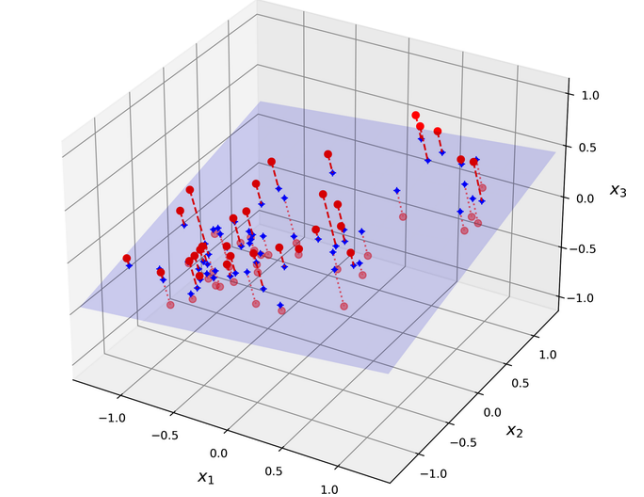

All the training instances lie close to that grey 2D plane: this is a lower-dimensional space. If we project every training instance perpendicularly onto this subspace (dashed lines), we get a new 2D dataset (figure below):

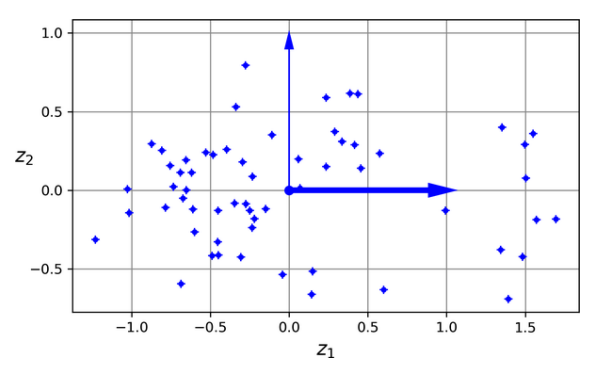

This solution is fast and often works well, but it is not always the case; take the below example of the Swiss roll dataset:

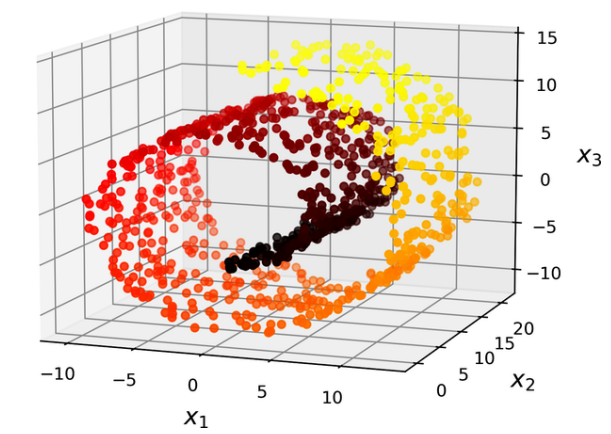

Projecting this into a 2D plane would result in different layers of the Swiss roll to fall close:

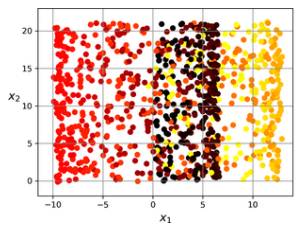

What you would like instead is something like this:

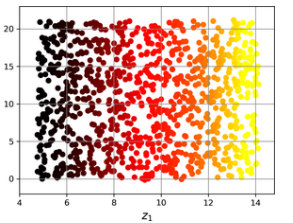

This has been obtained through **Manifold Learning**.

### Manifold Learning
A **Manifold** is a $d$-dimensional shape that can be bent and twisted in a $n$-dimensional space (with $d<n$) that locally resembles a $d$-dimensional hyperplane.

The Swiss roll is an example of a manifold with $d = 2$ and $n = 3$.

Many dimensionality reduction algorithms work by modeling the manifold on which the training instances lie: this is **Manifold Learning**. It relies on **Manifold Assumption** (or **Manifold Hypothesis**) which states that most real-world high-dimensioanl datasets lie close to a much lower-dimensional manifold.

Think of the MNIST dataset: all the images have similarities, meaning the degrees of freedom available to you if you try to create a digit image are dramatically lower than degrees of freedom if you are allowed to generate any image you want. These constraints tend to squeeze the dataset into a lower-dimensional manifold.

An added implicit assumption to the Manifold Assumption is that the task we want to perform will be simpler if expressed in the lower-dimensional space. Unfortunately, this is not always true, meaning that dimensionality reduction may speed up training, but won't always lead to a better or simpler solution.

## 4. Main Algorithms for Dimensionality Reduction

### PCA
**Principal Component Analysis (PCA)** is the most popular dimensionality reduction algorithm: it works by identifying the hyperplane that lies closest to data and then projects the data onto it.

#### Preserving the Variance
When selecting the hyperplane, PCA selects the one that **preserves the maximum amount of variance** (i.e., preserves the maximum amount of information).

Below a 2D graphical example:

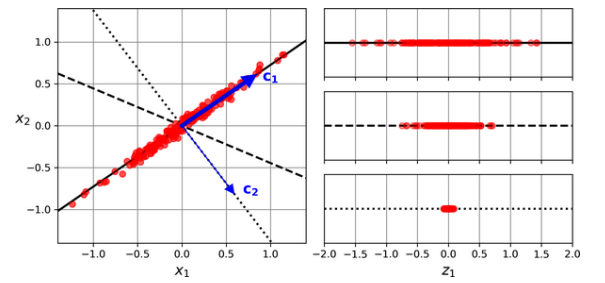

On the left we have the original data (red dots) and 3 different axis (1D hyperplane) on which to try to project the data. On the right we have the results of the 3 projections: top one preserved maximum variance, middle one an intermediate amount of variance, bottom one a very little amount of variance (the top one is the best in this case).

In ML terms, we choose the hyperplane minimizing the mean squared distance between the original dataset and its projection onto that hyperplane.

#### Principal Components
As we said, PCA identifies the first axis trying to preserve the maximum amount of variance; it then finds a second axis, orthogonal to the first one, trying to preserve the largest amount of the remaining variance and so on. The $i^{th}$ axis is called the $i^{th}$ **Principal Component (PC)**.

The PCs are found by a standard matrix factorization technique called **Singular Value Decomposition (SVD)**, which decompose the training set matrix $X$ into the product of three matrices $U\Sigma V^T$, where $V$ contains the unit vectors defining all the PCs you are looking for, in the correct order.

$$ V = (c_1 \space c_2 \space ... c_n)$$

We can use the `numpy.linalg.svd()` function to get the PCs of a training set (note how PCA assumes the dataset is centered around the origin):

In [3]:
import numpy as np

X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

X_centered = X - X.mean(axis=0)

U, s, Vt = np.linalg.svd(X_centered)

print("Principal Components:\n", Vt)

Principal Components:
 [[ 0.57735027  0.57735027  0.57735027]
 [-0.81649658  0.40824829  0.40824829]
 [ 0.         -0.70710678  0.70710678]]


#### Projecting Down to d Dimensions
We identified all the PCs; now we can reduce the dimensioanlity of the dataset down to $d$ dimensions by projecting it onto the hyperplane defined by the first $d$ PCs.

To project a training set $X$ onto the hyperplane and obtain a reduced dataset $X_{d-proj}$ of dimensionality $d$, we must compute the matrix multiplication of $X$ and $W_d$, which is the matrix containing the first $d$ columns of $V$:

$X_{d-proj} = XW_d$

Let's try to project the previous onto the plane defined by the first 2 PCs:

In [4]:
W2 = Vt[:2].T
X2D = X_centered @ W2

X2D

array([[-5.19615242e+00, -1.33226763e-15],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 5.19615242e+00,  1.33226763e-15]])

#### In Scikit-Learn
The Scikit-Learn's `PCA` class implements PCA using SVD (it also automatically care of centering the data):

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

X2D

array([[-5.19615242e+00, -2.56395025e-16],
       [ 0.00000000e+00, -0.00000000e+00],
       [ 5.19615242e+00, -2.56395025e-16]])

We can also access the `components_` attribute of the fitted `PCA` to get the transpose of $W_d$:

In [6]:
pca.components_

array([[ 0.57735027,  0.57735027,  0.57735027],
       [ 0.81649658, -0.40824829, -0.40824829]])

#### Explained Variance Ratio
We can inspect the parameter `explained_variance_ratio_` to understand the proportion of the dataset's variance that lies along each PCs:

In [7]:
pca.explained_variance_ratio_

array([1.00000000e+00, 2.43475588e-33])

This tells us that almost 100% of the dataset's variance lies along the first PC.

#### Choosing the Right Number of Dimensions
A good idea to get a right number of dimensions is to choose it so that the explained variance ratio is sufficiently large (e.g., 95%); of course if our goal is instead data visualization, we should arbitrarily reduce dimensionality to 2 or 3.

Below, the MNIST dataset is loaded and PCA is performed to preserve 95% of the training set's variance (note how giving a float between 0.0 and 1.0 to `n_components`, it interprets it as the desire explained variance ratio we want to preserve):

In [8]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

pca = PCA(n_components=0.95)
pca.fit(X_train)
pca.n_components_

np.int64(154)

Another option is to plot the explained variance as a function of the number of dimensions:

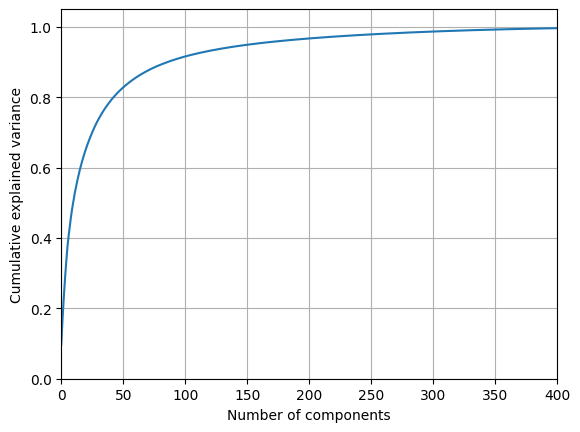

In [9]:
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumsum)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.xlim(0, 400)
plt.ylim(0, 1.05)
plt.grid()
plt.show()

As in our case, this curve usually has an elbow in which the explained variance stops growing fast (around 100 in our case), which could be a good spot for choosing the desired number of dimensions.

If you're using PCA as a preprocessing step of a Supervised task (e.g., Classification), you can tune the number of dimensions as you would tune any other hyperparameter:

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))

param_distribs = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}

rnd_search = RandomizedSearchCV(clf, param_distributions=param_distribs, n_iter=10, cv=3, random_state=42)
rnd_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'pca__n_components': array([10, 11... 78, 79]), 'randomforestclassifier__n_estimators': array([ 50, ...97, 498, 499])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Let's inspect the best hyperparameters found:

In [40]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(304), 'pca__n_components': np.int64(62)}


#### PCA for Compression
Applying PCA to the MNIST preserving 95% of variance took from 784 features to 154, compressing the size of the dataset to less than 20% of its original. 

It is also possible to decompress the reduced dataset back to 784 dimensions applying the inverse transformation of the PCA:

$$X_{recovered} = X_{d-proj}W_d^T$$

This won't give you the original dataset back, but one very close to it: the mean squared distance between the original data and the reconstructed one is called **Reconstruction Error**.

In [41]:
X_reduced = pca.transform(X_train)
X_recovered = pca.inverse_transform(X_reduced)

We could also print these recovered images and see how they are almost identical to the original ones:

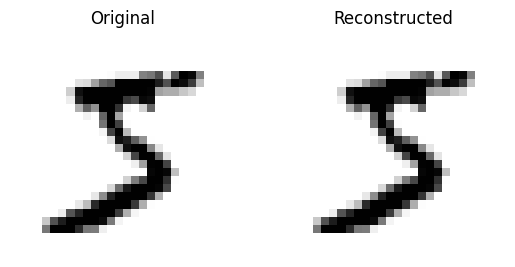

In [42]:
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(X_train[0].reshape(28, 28), cmap="binary")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Reconstructed")
plt.imshow(X_recovered[0].reshape(28, 28), cmap="binary")
plt.axis("off")

plt.show()

#### Randomized PCA
By setting the parameter `svd_solver="randomized"`, a stochastic implementation called **Randomized PCA** is instead performed: this quickly finds an approximation of the first $d$ principal component. The computational complexity of this is $O(m \times d^2) + O(d^3)$ instead of the one of the full SVD approach which is $O(m \times n^2) + O(n^3)$, meaning it is much faster when $d$ is much smaller than $n$.

In [43]:
rnd_PCA = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_PCA.fit_transform(X_train)

Note how by default, the parameter `svd_solver` is set to `"auto"` and based on some conditions, the algorithm used is different:
- `"covariance_eigh"` is used when input has few features ($n < 1,000$) and at least 10 times more samples ($m > 10n$);
- `"randomized"` is used when $max(m, n) > 500$ and `n_components` is an integer smaller than $80\% \space min(m, n)$;
- `"full"`, meaning full SVD, is used in all other cases.

#### Incremental PCA
**Incremental PCA (IPCA)** algorithms allow to split training set into mini-batches and feed these one at a time, allowing to fit PCA even for training sets which don't fit in memory or to fit it online (on the fly as new instances arrive). You can implement it with the class `IncrementslPCA` (must split data into batches using `numpy.array_split()` and then call `partial_fit()` instead of `fit()`):

In [10]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)
    
X_reduced = inc_pca.transform(X_train)

Alternatively, you can use `numpy.memmap` class (memmap stands for **Memory-Mapped**), which allows to manipulate large array stored in a binary file on disk as if it were entirely in memory:

First, we create a memmap file and we copy the MNIST training set to it; then we call `flush()` to ensure any data in cache get saved to disk (in a real case, `X_train` wouldn't fit in memory, so you would load it chunk by chunk to save it in the memmap file):

In [ ]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train # here we would load X_train chunk by chunk in a real case
X_mmap.flush()

We can then load the memmap file and use it like a regular NumPy array. If we want to use `IncrementalPCA` on it, we could also call the `fit()` method, instead of `partial_fit()`, which is convenient (note how only the binary data is saved to disk, so we need to specify data type and shape, otherwise a 1D array will be returned):

In [12]:
X_mmap = np.memmap(filename, dtype='float32', mode='readonly').reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

,n_components,154
,whiten,False
,copy,True
,batch_size,600


### Random Projection
As we said, PCA can be slow on high-dimensional dataset (and randomized PCA doesn't change the complexity). When dealing with very large dataset (tens of thousands of features or more) we should consider using **Random Projection**: this technique projects data into a lower-dimensional space using a random linear projection (even if it sounds crazy, it is mathematically demonstrated to be effective).

The idea is that **Johnson and Lindestrauss** came up with an equation which determines the minimum number of dimensions to preserve in order to ensure, with high probability, that distances won't change more than a given tolerance (the distance between very different instances remain high, while the distance between very similar instances remain low). The equation is:

$$d \ge 4 \log(m) / (\frac 1 2 \epsilon^2 - \frac 1 3 \epsilon^3)$$

where $\epsilon$ is the tolerance we introduced (notice the function doesn't use $n$!).

In Scikit-Learn, we can implement this equation with the function `johnson_lindenstrauss_min_dim()`:

In [13]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, e = 5000, 0.1
d = johnson_lindenstrauss_min_dim(n_samples=m, eps=e)
d

np.int64(7300)

We'll now generate a random datasaset with $n$ dimensions where each item is sampled from a Gaussian distribution with mean 0 and variance $\frac 1 d$ and project it down to $d$ dimensions:

In [14]:
n = 20000
rng = np.random.default_rng(seed = 42)
P = rng.standard_normal((d, n)) / np.sqrt(d)

X = rng.standard_normal((m, n))
X_reduced = X @ P.T

Scikit-Learn provides a `GaussianRandomProjection` class which implements what we just did: when calling `fit()` it gets the number of dimensions with the Johnson Lindestrauss equation and generates the random matrix (this is stored in `components_`); then when calling `transform()` it uses that to perform projection. You can also put specific `eps` and `d` values if needed (these can be fine-tuned using CV).

In [15]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=e, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

Scikit-Learn also provides `SparseRandomProjection` which uses the same algorithm, but the random matrix is sparse, taking it to be faster (about 50% in the previous example) and to use much less memory (25 MB instead of 1.2 GB in the previous example). The output is only very slightly less accurate, but it is strongly comparable. At the end, this last class is almost always preferable.

This class also allows to choose the ratio of nonzero items in the sparse random matrix (this is called **density**), which by default is $\frac 1 {\sqrt n}$, by setting the `density` hyperparameter.

We can also perform the inverse transformation, but to do so we'll need to first compute the pseudoinverse with `numpy.linalg.pinv()` and multiply the reduced data by the transpose of it.

### Locally Linear Embedding (LLE)
**Locally Linear Embedding (LLE)** is a **NonLinear Dimensionality Reduction (NLDR)** technique. It is a Manifold Learning technique, not relying on projections. It basically uses k-nearest neighbors to first determines how each training instance $x^{(i)}$ linearly relates to its nearest neighbors (default is $k = 10$), then it looks for a low-dimensional representation where those local relationships are best preserved by reconstructing $x^{(i)}$ as a linear function of those neighbors: this means to find the weights $w_{i, j}$ to minimize the squared distance between $x^{(i)}$ and $\sum_{j = 1}^m w_{i, j}x^{(j)}$.

We can represent the encoding of the local linear relationships between training instances as the contrained optimization problem:

$$\hat W = \argmin_W \sum_{i = 1}^m(x^{(i)} - \sum_{j = 1}^m w_{i, j} x^{(j)})^2$$
$$\text{subject to } \left \{ \begin{array}{l} w_{i, j} = 0 & \text{if }x^{(j)} \text{ is not one of the } k \text{ n.n of } x^{(i)} \\ \sum_{j = 1}^m w_{i, j} = 1 & \text{for } i = 1, 2, ..., m \end{array} \right.$$

We then want the image $z^{(i)}$ of $x^{(i)}$ in this d-dimensional space to preserve as much as possible these local relationships, so we want to minimize $\sum_{j = 1}^m \hat w_{i, j}z^{(j)}$.

This takes to the unconstrained problem:

$$\hat Z = \argmin_Z \sum_{i = 1}^m(z^{(i)} - \sum_{j = 1}^m \hat w_{i, j} z^{(j)})^2$$

This algorithms has complexity of:
- $O(m \log(m)n \log(k))$ for finding the k-nearest neighbors;
- $O(mnk^3)$ for optimizing the weights;
- $O(dm^2)$ for constructing the representation.

The last $m^2$ term makes this not scale well with large datasets.

We can implement it on the Swiss roll using `LocallyLinarEmbedding` class:

In [1]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swoss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swoss)

(the $t$ variable is a 1D NumPy array containing the position of each instance along the rolled axis, making it a good target for a regression task, which we won't perform here)

If we plot the resulting array:

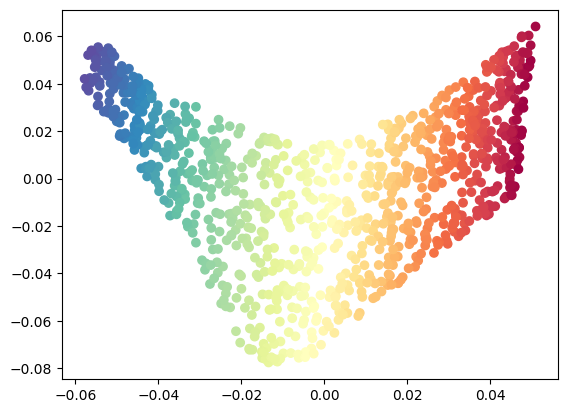

In [19]:
plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1], c=t, cmap=plt.cm.Spectral)

As we see, we unrolled the Swiss roll preserving local distances. However, distances are not preserved on a larger scale: the unrolled should be a rectangle, not this stretched band. Still, LLE did a good job of modeling the manifold.

### Others
- `sklearn.manifold.MDS` (**MultiDimensional Scaling (MDS)**): similar to Random Projection but more efficient with low-dimensional data;
- `sklearn.manifold.Isomap` (**Isomap**): creates a graph connecting each instance to its nearest neighbors, then reduces dimensionality preserving the **Geodesic Distances** (number of nodes in the shortest path between 2 nodes); works well with smooth and low-dimensional manifold with single global structure (e.g., Swiss Roll);
- `sklearn.manifold.TSNE` (**t-distributed Stochastic Neighbor Embedding (t-SNE)**): mainly used for visualization, in particular to visualize clusters of instances in high-dimensional space;
- `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` (**Linear Discriminant Analysis (LDA)**): linear classification algorithm which during training learns the most discriminative axes between classes, which can then be used to define an hyperplane onto which to project data (generally useful to reduce dimensionality before running another classification, or as classification algorithm alone if sufficient);
- `umap.UMAP()` (**Uniform Manifold Approximation and Projection (UMAP)**): mainly used for visualization; while t-SNE is better at preserving local structure, UMAP tries to preserve both local and global structure; moreover, it scales better with large datasets.

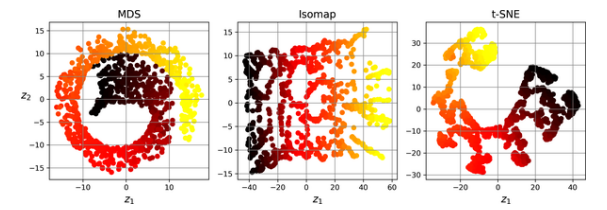